# V2 : 
# log transform outside pipeline
# Variance selection 1st quartile

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import learning_curve, LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, SelectFromModel, SelectFpr, VarianceThreshold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

In [2]:
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/old_metabolome_paul.xlsx"
dataset_val_path = "C:/Users/tamer/Documents/PhD/ML/old_metabolome_saqib.xlsx"

df = pd.read_excel(dataset_total_path)
df_val = pd.read_excel(dataset_val_path)

print(df.shape)
print(df_val.shape)

(24, 240)
(12, 240)


In [3]:
Class_A = 'LP'
Class_B = 'LN'

df = df[(df["Class"] == Class_A) | (df["Class"] == Class_B)]
df_val = df_val[(df_val["Class"] == Class_A) | (df_val["Class"] == Class_B)]

In [4]:
def encodage(df):
    code = {
    'LP' : 1,
    'SP' : 0,
    'LN' : 3,
    'SN' : 4
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [5]:
X_total, y_total = preprocessing(df)
X_val, y_val = preprocessing(df_val)

Class
3    6
1    6
Name: count, dtype: int64
Class
3    3
1    3
Name: count, dtype: int64


In [6]:
print("var before log2 transormation : " , X_total.var(axis=0).mean())
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
X_total = log2_transformer.fit_transform(X_total)
X_val = log2_transformer.fit_transform(X_val)
print("var after log2 transormation : " , X_total.var(axis=0).mean())

var before log2 transormation :  1.5954927629222294e+17
var after log2 transormation :  0.33535736756433454


In [7]:
def evaluation(model):
    model.fit(X_total, y_total)
    ypred = model.predict(X_val)
    cm = confusion_matrix(y_val, ypred)
    report = classification_report(y_val, ypred)
    
    print(confusion_matrix(y_val, ypred))
    print(classification_report(y_val, ypred))

    # evaluation du modèle en fonction du nombre de samples, basé sur le f1 score
    # Evalue si underfit ou overfit
    N, train_score, val_score = learning_curve(model, X_total, y_total, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(10,6))
    # on prend les .means de chaque round de cv. cv = 4 <=> on sépare le dataset en 4 et prend 3 part = train 1 part = test, puis on échange
    plt.plot(N, train_score.mean(axis=1), label = 'train score')
    plt.plot(N, val_score.mean(axis=1), label = 'val score')
    plt.legend()

    path = "C:/Users/tamer/Documents/PhD/ML/metrics.txt"
    with open(path, 'a', encoding='utf-8') as f:
        f.write(f"\n==== {model} ====\n")
        f.write("Confusion matrix:\n")
        f.write(str(cm) + "\n")
        f.write("Classification report:\n")
        f.write(report + "\n")
        f.write("="*40 + "\n")

In [ ]:
vars_ = X_total.var(axis=0)
q1 = np.quantile(vars_, 0.25)   # or np.percentile(vars_, 25)
#vars_.median()

selector = VarianceThreshold(threshold = q1)
#preprocessor = make_pipeline(selector)

preprocessor = make_pipeline(SelectKBest(score_func=f_classif, k=240))

LR_L1 = make_pipeline(preprocessor, StandardScaler(), LogisticRegression(penalty='l1', random_state = 0, solver = 'liblinear'))
evaluation(LR_L1)


C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tamer\anaconda3\Lib\site-packag

[[0 3]
 [0 3]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           3       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:108: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarn

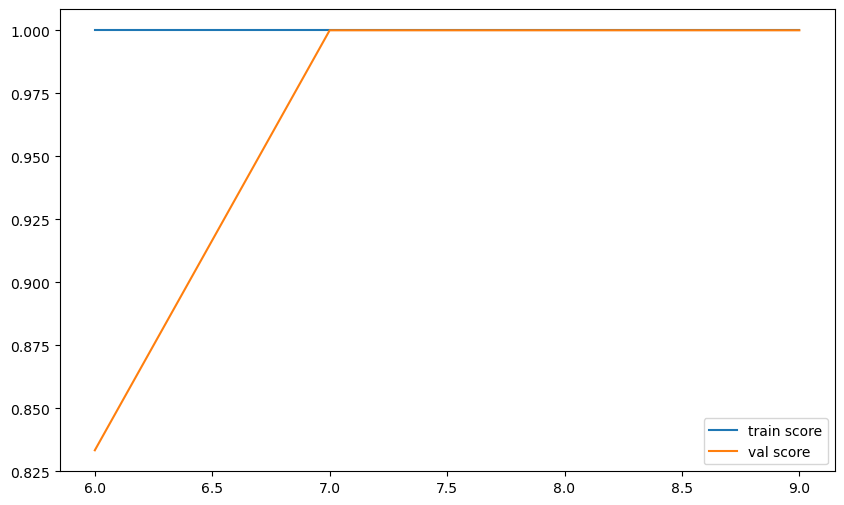